In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

NGC = "NGC6809"
cx_list = [f"CX{i}" for i in range(1, 32)]

In [45]:
path_optical = f'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/{NGC}_optical.csv'
path_xray = f'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/{NGC}_xray.csv'


    # Data from all optical sources
optical_data = pd.read_csv(path_optical)

    # Data from all x_rays
xray_data = pd.read_csv(path_xray, index_col = "id")

In [77]:
data_list = []
for CX in cx_list:
    df_Data = optical_data[["RA", "Decl", "Id"]]
    ra = df_Data["RA"].values
    dec = df_Data["Decl"].values    
    ra0 = xray_data.loc[CX, "RA"]
    dec0 = xray_data.loc[CX, "Decl"]
    
         
    dist = np.sqrt(
        ((ra - ra0) * np.cos(np.deg2rad(dec)))**2 +
        (dec - dec0)**2
    )
    inner_circle_sources = np.where(dist < 0.6/3600)[0].tolist()
    radius = "0.6"           
    if len(inner_circle_sources) == 0:
        inner_circle_sources = np.where(dist < 2/3600)[0].tolist()
        radius = "2"
    n = optical_data.loc[inner_circle_sources]
    
    for num, sources in enumerate(inner_circle_sources):
        Mv = optical_data.loc[sources]["Mv"]
        xray_L = xray_data.loc[CX]["log(Lx_0.5-2.5)"]
        zzz = 0.4 * Mv + xray_L
        if zzz < 34:
            optical_xray_classification = "AB"
        elif zzz >= 34 and zzz < 36.2:
            optical_xray_classification = "CV"
        else:
            optical_xray_classification = "LMXRB"
        new_row_data = {'id': f"{CX}_{num+1}",
                        'Hardness_classification': xray_data.loc[CX]["Hardness_classification"],
                        'Mv vs xray': optical_xray_classification,
                        'pos_0' : optical_data.loc[sources]["position_0"],
                        '275 - 336' : optical_data.loc[sources]["275 - 336"],
                        '336_Mag' : optical_data.loc[sources]["336_Mag"],
                        'pos_1' : optical_data.loc[sources]["position_1"],
                        '438 - 606' : optical_data.loc[sources]["438 - 606"],
                        '606_Mag' : optical_data.loc[sources]["606_Mag"],
                        'pos_2' : optical_data.loc[sources]["position_2"],
                        '606 - 814' : optical_data.loc[sources]["606 - 814"],
                        '814_Mag' : optical_data.loc[sources]["814_Mag"],
                        'radius' : radius,
                        '#sources' : len(inner_circle_sources)}
        data_list.append(new_row_data)
        


In [78]:
df = pd.DataFrame(data_list)
df

,id,Hardness_classification,Mv vs xray,pos_0,275 - 336,336_Mag,pos_1,438 - 606,606_Mag,pos_2,606 - 814,814_Mag,radius,#sources
0,CX2_1,CV & AB,CV,MS,1.5019,21.5343,MS,1.0964,20.4450,MS,0.7717,19.6733,0.6,1
1,CX8_1,CV & AB,AB,bluer than MS L1,0.8844,17.5024,Red giant branch,0.9845,16.6808,Red giant branch,0.7291,15.9517,0.6,1
2,CX9_1,CV & AB,AB,bluer than MS L1,0.5231,17.8890,bluer than MS L1,0.5940,17.5223,bluer than MS L1,0.5163,17.0060,2,6
3,CX9_2,CV & AB,AB,MSTO,0.6434,17.8927,MS,0.6786,17.4505,MS,0.5864,16.8641,2,6
4,CX9_3,CV & AB,AB,MS,1.6307,21.8747,MS,1.2093,20.5491,MS,0.8173,19.7318,2,6
5,CX9_4,CV & AB,AB,MS,1.7096,21.3682,MS,1.1121,20.3108,MS,0.7835,19.5273,2,6
6,CX9_5,CV & AB,AB,MS,1.4877,21.2895,MS,1.1386,20.2866,MS,0.7681,19.5185,2,6
7,CX9_6,CV & AB,AB,MS,0.8743,19.9259,MS,0.8508,19.3930,MS,0.6668,18.7262,2,6
8,CX11_1,CV & AB,AB,MS,1.1918,20.9660,MS,1.0411,20.0250,MS,0.6837,19.3413,0.6,2
9,CX11_2,CV & AB,AB,MS,0.7644,19.2042,MS,0.8172,18.8580,MS,0.5997,18.2583,0.6,2


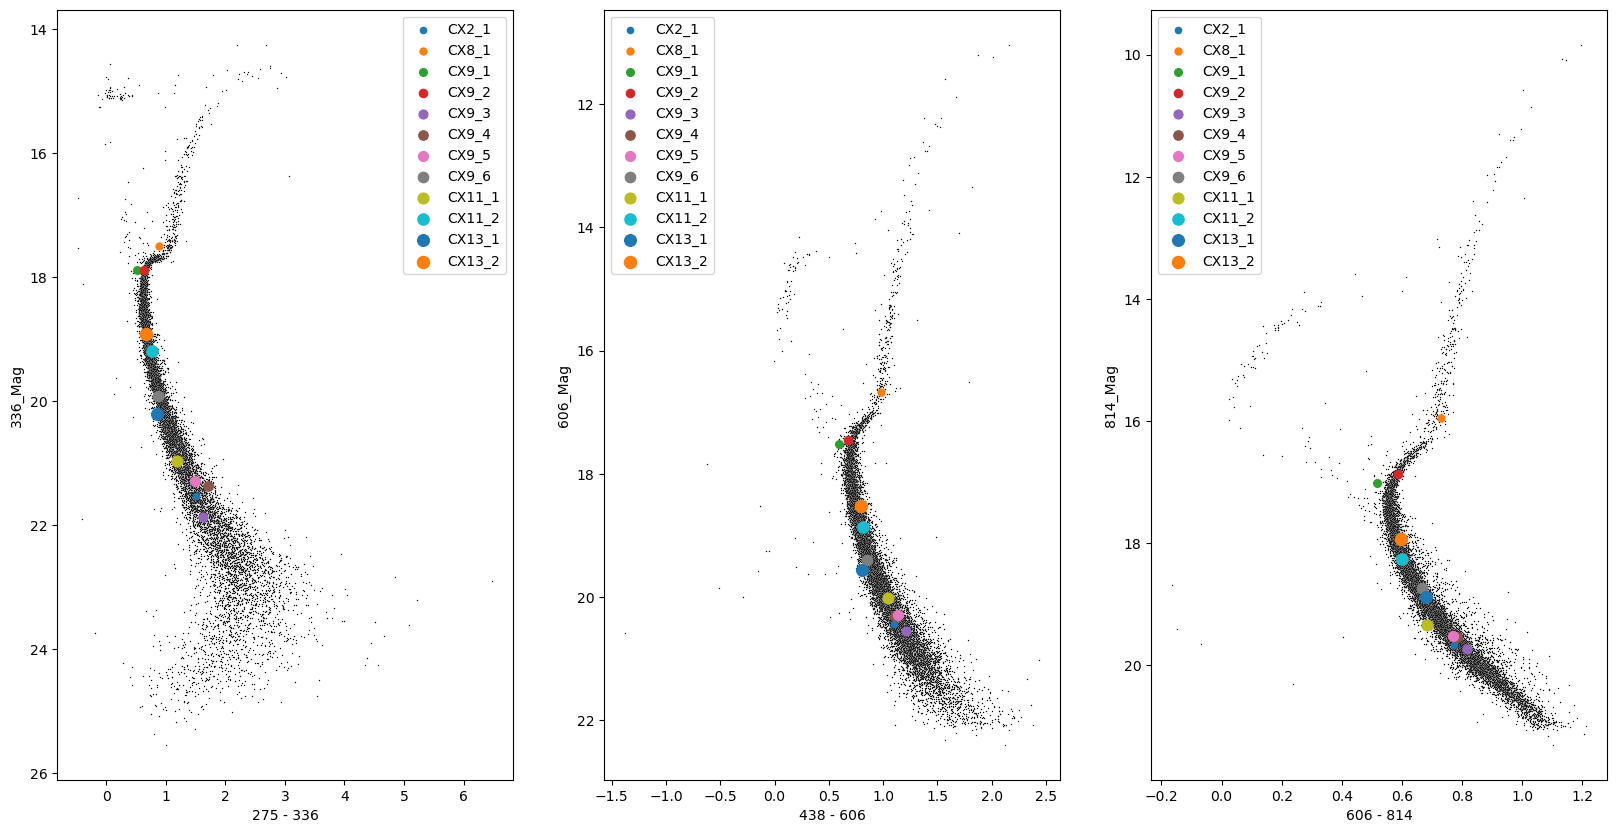

In [85]:
fig, axes = plt.subplots(ncols = 3, figsize=(20, 10))

pairs = [("275", "336"), ("438", "606"), ("606", "814")]

for gráfico_comp in range(3):

    Color1, Color2 = pairs[gráfico_comp]

    sns.scatterplot(
        data=optical_data,
        x=f"{Color1} - {Color2}",
        y=f"{Color2}_Mag",
#        hue="position_0",
        color = "black",
        s=1,
        legend=False,
        ax=axes[gráfico_comp]
    )

    for i in range(12):
        axes[gráfico_comp].scatter(
            df.loc[i][f"{Color1} - {Color2}"],
            df.loc[i][f"{Color2}_Mag"],
            s=20+i*5,
            label=df.loc[i]["id"]
        )

    axes[gráfico_comp].invert_yaxis()
    axes[gráfico_comp].legend()

plt.show()

In [86]:
df

,id,Hardness_classification,Mv vs xray,pos_0,275 - 336,336_Mag,pos_1,438 - 606,606_Mag,pos_2,606 - 814,814_Mag,radius,#sources
0,CX2_1,CV & AB,CV,MS,1.5019,21.5343,MS,1.0964,20.4450,MS,0.7717,19.6733,0.6,1
1,CX8_1,CV & AB,AB,bluer than MS L1,0.8844,17.5024,Red giant branch,0.9845,16.6808,Red giant branch,0.7291,15.9517,0.6,1
2,CX9_1,CV & AB,AB,bluer than MS L1,0.5231,17.8890,bluer than MS L1,0.5940,17.5223,bluer than MS L1,0.5163,17.0060,2,6
3,CX9_2,CV & AB,AB,MSTO,0.6434,17.8927,MS,0.6786,17.4505,MS,0.5864,16.8641,2,6
4,CX9_3,CV & AB,AB,MS,1.6307,21.8747,MS,1.2093,20.5491,MS,0.8173,19.7318,2,6
5,CX9_4,CV & AB,AB,MS,1.7096,21.3682,MS,1.1121,20.3108,MS,0.7835,19.5273,2,6
6,CX9_5,CV & AB,AB,MS,1.4877,21.2895,MS,1.1386,20.2866,MS,0.7681,19.5185,2,6
7,CX9_6,CV & AB,AB,MS,0.8743,19.9259,MS,0.8508,19.3930,MS,0.6668,18.7262,2,6
8,CX11_1,CV & AB,AB,MS,1.1918,20.9660,MS,1.0411,20.0250,MS,0.6837,19.3413,0.6,2
9,CX11_2,CV & AB,AB,MS,0.7644,19.2042,MS,0.8172,18.8580,MS,0.5997,18.2583,0.6,2
